In [7]:
# This code trys to predict what number the given 28 x 28, black and white, images are.

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import math as math

#Links to folders with test_images and converted_images
fp_in = r'/Users/seang/Documents/bnl/Exercise_1/test_images'
fp_out = r'/Users/seang/Documents/bnl/Exercise_1/processed_test_images'

custom_images = []
custom_labels = []

#folder test
if not os.path.exists(fp_out):
    os.makedirs(fp_out)

#converting images to something keras can process
def image_configure(file_path):
    image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    image_resize = cv2.resize(image, (28, 28), interpolation=cv2.INTER_AREA)
    image_invert = cv2.bitwise_not(image_resize)
    _, binary_image = cv2.threshold(image_invert, 128, 255, cv2.THRESH_BINARY)
    image_processed = binary_image.reshape(28, 28)
    # image_processed = image_invert.reshape(28,28)
    
    return image_processed

#using image_configure and saving images to new folder
for filename in os.listdir(fp_in):
    if filename.endswith((".jpeg")):
        path = os.path.join(fp_in, filename)
        image_new = image_configure(path)
        save_path = os.path.join(fp_out, f"resized_{filename}")
        cv2.imwrite(save_path, image_new)

        name_only = os.path.splitext(filename)[0]
        label = int(name_only[-1])
        
        custom_images.append(image_new)
        custom_labels.append(label)

#normalized images
norm_custom_images = np.array(custom_images) / 255.0
norm_custom_labels = np.array(custom_labels)

#from example
def show_sample(images, labels, sample_count=25):
    # Create a square with can fit {sample_count} images
    grid_count = math.ceil(math.ceil(math.sqrt(sample_count)))
    grid_count = min(grid_count, len(images), len(labels))
  
    plt.figure(figsize=(2*grid_count, 2*grid_count))
    for i in range(sample_count):
        plt.subplot(grid_count, grid_count, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.gray)
        plt.xlabel(labels[i])
    plt.show()

In [2]:
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images / 255.0

In [3]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

/Users/seang/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 514us/step - accuracy: 0.8758 - loss: 0.4362
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 510us/step - accuracy: 0.9644 - loss: 0.1237
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 508us/step - accuracy: 0.9763 - loss: 0.0798
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 513us/step - accuracy: 0.9816 - loss: 0.0598
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 508us/step - accuracy: 0.9862 - loss: 0.0442


In [5]:
test_loss, test_acc = model.evaluate(norm_custom_images, norm_custom_labels)

print('Test accuracy:', test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4400 - loss: 2.7879
Test accuracy: 0.4399999976158142


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


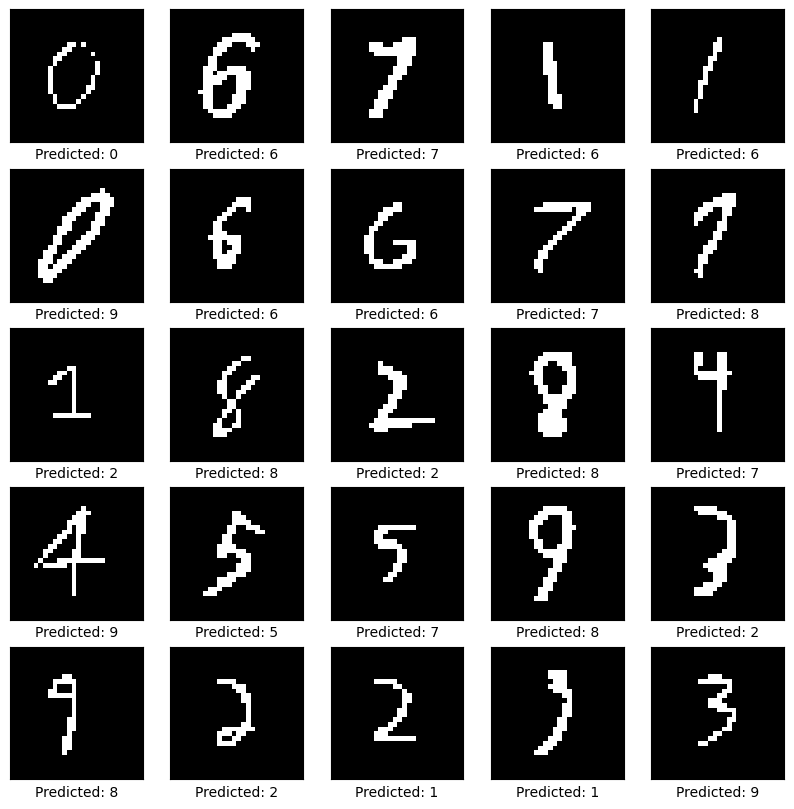

In [6]:
predictions = model.predict(norm_custom_images)

show_sample(norm_custom_images, 
            ['Predicted: %d' % np.argmax(result) for result in predictions])